In [1]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-31 18:43:34.005286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780253014.209939      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780253014.266058      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780253014.731691      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780253014.731738      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780253014.731742      58 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_PATH = "/kaggle/input/datasets/nikitarom/planets-dataset/planet/planet"

CSV_PATH = os.path.join(
    DATASET_PATH,
    "train_classes.csv"
)

IMAGE_DIR = os.path.join(
    DATASET_PATH,
    "train-jpg"
)

OUTPUT_DIR = "/kaggle/working/outputs"

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "tables"
)

MODEL_DIR = os.path.join(
    OUTPUT_DIR,
    "models"
)

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(os.path.exists(CSV_PATH))
print(os.path.exists(IMAGE_DIR))

True
True


In [3]:
df = pd.read_csv(CSV_PATH)

df["tags"] = df["tags"].apply(
    lambda x: x.split(" ")
)

mlb = MultiLabelBinarizer()

encoded_labels = mlb.fit_transform(
    df["tags"]
)

label_names = mlb.classes_

label_df = pd.DataFrame(
    encoded_labels,
    columns=label_names
)

dataset_df = pd.concat(
    [
        df["image_name"],
        label_df
    ],
    axis=1
)

print(dataset_df.shape)

display(dataset_df.head())

(40479, 18)


,image_name,agriculture,artisinal_mine,bare_ground,blooming,blow_down,clear,cloudy,conventional_mine,cultivation,habitation,haze,partly_cloudy,primary,road,selective_logging,slash_burn,water
0,train_0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
1,train_1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,train_2,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,train_3,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,train_4,1,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0


In [4]:
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(valid_df))
print("Testing:", len(test_df))

Training: 28335
Validation: 6072
Testing: 6072


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(image_name):

    image_path = os.path.join(
        IMAGE_DIR,
        image_name + ".jpg"
    )

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype(np.float32)

    image = image / 255.0

    return image

In [6]:
class PlanetDataGenerator(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        dataframe,
        batch_size=32,
        shuffle=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.batch_size = batch_size

        self.shuffle = shuffle

        self.indexes = np.arange(
            len(self.dataframe)
        )

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.floor(
                len(self.dataframe) /
                self.batch_size
            )
        )

    def __getitem__(
        self,
        index
    ):

        indexes = self.indexes[
            index*self.batch_size:
            (index+1)*self.batch_size
        ]

        batch_df = self.dataframe.iloc[indexes]

        images = []

        labels = []

        for _, row in batch_df.iterrows():

            image = load_image(
                row["image_name"]
            )

            label = row.iloc[1:].values.astype(
                np.float32
            )

            images.append(image)

            labels.append(label)

        return (
            np.array(images),
            np.array(labels)
        )

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(
                self.indexes
            )

train_generator = PlanetDataGenerator(
    train_df,
    batch_size=BATCH_SIZE
)

valid_generator = PlanetDataGenerator(
    valid_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = PlanetDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Generators Ready")

Generators Ready


In [7]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.15
    ),

    tf.keras.layers.RandomZoom(
        0.15
    )

])

base_model = tf.keras.applications.EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(
    inputs
)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(
    0.4
)(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

outputs = tf.keras.layers.Dense(
    len(label_names),
    activation="sigmoid"
)(x)

efficientnet_model = tf.keras.Model(
    inputs,
    outputs
)

efficientnet_model.summary()

2026-05-31 18:43:49.412315: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         8,721 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,714,164 (17.98 MB)

 Trainable params: 664,593 (2.54 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
efficientnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy"
        )
    ]
)

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=2
)

history = efficientnet_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=2,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/2
885/885 ━━━━━━━━━━━━━━━━━━━━ 1452s 2s/step - binary_accuracy: 0.9038 - loss: 0.2628 - val_binary_accuracy: 0.9069 - val_loss: 0.2551 - learning_rate: 0.0010
Epoch 2/2
885/885 ━━━━━━━━━━━━━━━━━━━━ 1409s 2s/step - binary_accuracy: 0.9045 - loss: 0.2586 - val_binary_accuracy: 0.9069 - val_loss: 0.2540 - learning_rate: 0.0010


In [9]:
efficientnet_model.save(

    os.path.join(
        MODEL_DIR,
        "efficientnetb0_model.keras"
    )
)

print("EfficientNetB0 Saved")

EfficientNetB0 Saved


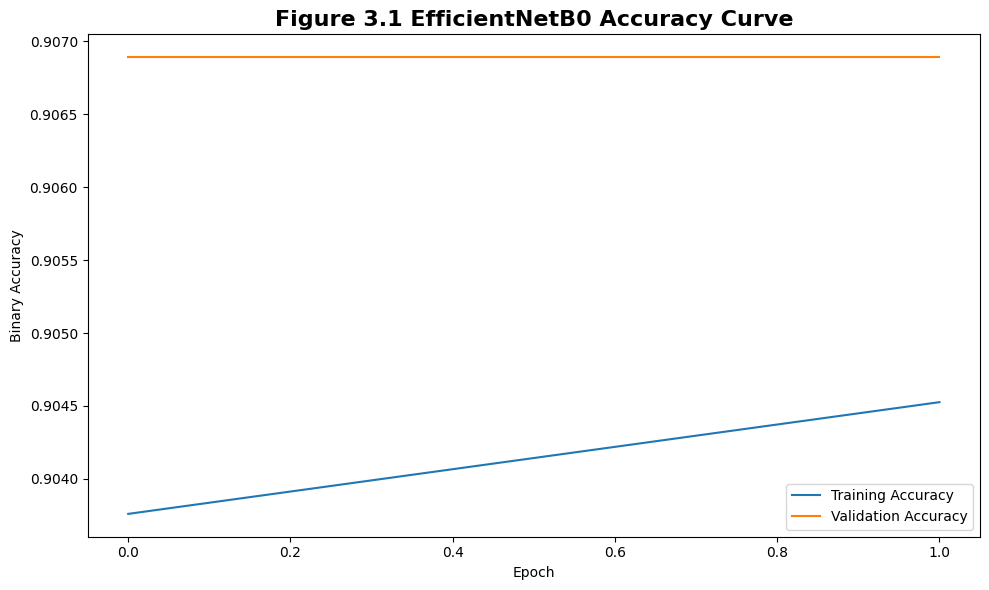

In [10]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history["binary_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_binary_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Figure 3.1 EfficientNetB0 Accuracy Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")

plt.ylabel("Binary Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "efficientnetb0_accuracy_curve.pdf"
    )
)

plt.show()

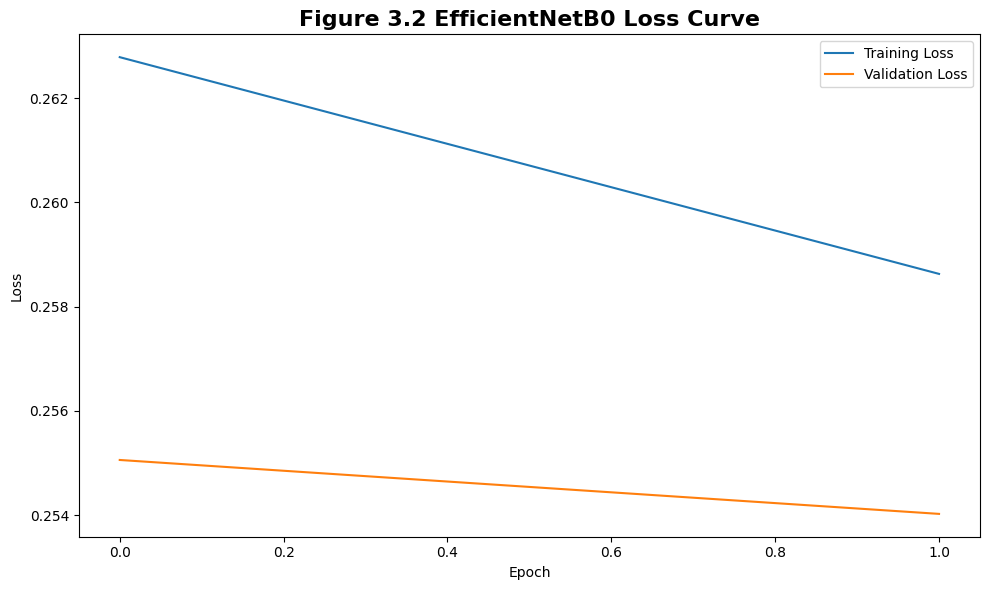

In [11]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Figure 3.2 EfficientNetB0 Loss Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "efficientnetb0_loss_curve.pdf"
    )
)

plt.show()

In [12]:
results = efficientnet_model.evaluate(
    test_generator
)

metrics_df = pd.DataFrame({

    "Metric": efficientnet_model.metrics_names,

    "Value": results

})

metrics_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "efficientnetb0_metrics.csv"
    ),

    index=False
)

metrics_df

189/189 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - binary_accuracy: 0.9063 - loss: 0.2557


,Metric,Value
0,loss,0.255749
1,compile_metrics,0.906328


In [13]:
predictions = efficientnet_model.predict(
    test_generator
)

y_pred = (
    predictions > 0.5
).astype(int)

y_true = []

for _, labels in test_generator:

    y_true.extend(labels)

y_true = np.array(y_true)

report = classification_report(

    y_true,

    y_pred,

    target_names=label_names,

    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "efficientnetb0_classification_report.csv"
    )
)

report_df.head()

189/189 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step


,precision,recall,f1-score,support
agriculture,0.0,0.0,0.0,1828.0
artisinal_mine,0.0,0.0,0.0,46.0
bare_ground,0.0,0.0,0.0,145.0
blooming,0.0,0.0,0.0,52.0
blow_down,0.0,0.0,0.0,10.0


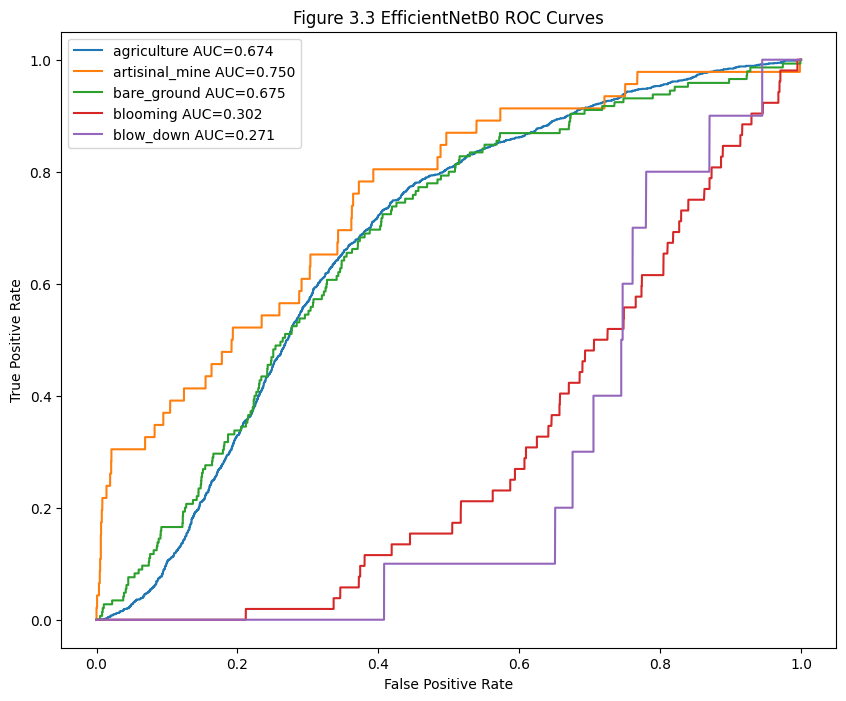

In [14]:
plt.figure(figsize=(10,8))

for i in range(5):

    fpr, tpr, _ = roc_curve(
        y_true[:,i],
        predictions[:,i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{label_names[i]} AUC={roc_auc:.3f}"
    )

plt.title(
    "Figure 3.3 EfficientNetB0 ROC Curves"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "efficientnetb0_roc_curve.pdf"
    )
)

plt.show()

In [15]:
confusion_matrices = multilabel_confusion_matrix(

    y_true,

    y_pred
)

print(
    confusion_matrices.shape
)

print("="*70)
print("NOTEBOOK 3 COMPLETED SUCCESSFULLY")
print("="*70)

print("""
Generated Outputs

efficientnetb0_model.keras

efficientnetb0_accuracy_curve.pdf

efficientnetb0_loss_curve.pdf

efficientnetb0_roc_curve.pdf

efficientnetb0_metrics.csv

efficientnetb0_classification_report.csv
""")

(17, 2, 2)
NOTEBOOK 3 COMPLETED SUCCESSFULLY

Generated Outputs

efficientnetb0_model.keras

efficientnetb0_accuracy_curve.pdf

efficientnetb0_loss_curve.pdf

efficientnetb0_roc_curve.pdf

efficientnetb0_metrics.csv

efficientnetb0_classification_report.csv

